In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [4]:
import data.d_load

bt, at = data.d_load.load()

In [5]:
bt

,update_id,best_bid_price,best_bid_qty,best_ask_price,best_ask_qty,transaction_time,event_time
0,4264349177374,64020.3,1.790,64020.4,3.636,1711238400018,1711238400024
1,4264349179250,64020.3,1.790,64020.4,3.634,1711238400033,1711238400039
2,4264349179655,64020.3,1.790,64020.4,3.640,1711238400037,1711238400044
3,4264349181766,64020.3,2.002,64020.4,3.640,1711238400049,1711238400058
4,4264349184343,64020.3,2.052,64020.4,3.640,1711238400064,1711238400073
...,...,...,...,...,...,...,...
91449742,4312569098807,69642.0,0.660,69642.1,3.074,1711843199631,1711843199637
91449743,4312569103997,69642.0,0.660,69642.1,3.071,1711843199735,1711843199741
91449744,4312569105328,69642.0,0.660,69642.1,3.074,1711843199775,1711843199780
91449745,4312569109173,69642.0,0.660,69642.1,3.076,1711843199878,1711843199885


In [6]:
at

,agg_trade_id,price,quantity,first_trade_id,last_trade_id,transact_time,is_buyer_maker
0,2096641851,64020.4,3.194,4790419953,4790419970,1711238400088,False
1,2096641852,64021.2,0.003,4790419971,4790419971,1711238400094,False
2,2096641853,64022.0,0.002,4790419972,4790419972,1711238400094,False
3,2096641854,64022.2,0.004,4790419973,4790419973,1711238400094,False
4,2096641855,64023.8,0.004,4790419974,4790419974,1711238400095,False
...,...,...,...,...,...,...,...
10893227,2107535078,69642.2,0.009,4817720262,4817720262,1711843198883,True
10893228,2107535079,69642.1,0.258,4817720263,4817720263,1711843198883,True
10893229,2107535080,69642.0,0.238,4817720264,4817720265,1711843198883,True
10893230,2107535081,69642.1,0.220,4817720266,4817720267,1711843198941,False


In [7]:
import params.sigma

mid, deduped = params.sigma.build_mid(bt)
rolling_sigma = params.sigma.estimate_rolling_vol(mid)
ewma_sigma = params.sigma.estimate_ewma_vol(mid)

rolling_sigma = params.sigma.slice_window(rolling_sigma)
ewma_sigma = params.sigma.slice_window(ewma_sigma)

In [8]:
mid

,mid_price
transaction_time,
2024-03-24 00:00:00,NaN
2024-03-24 00:00:01,64026.70
2024-03-24 00:00:02,64027.50
2024-03-24 00:00:03,64027.50
2024-03-24 00:00:04,64027.50
...,...
2024-03-30 23:59:55,69643.05
2024-03-30 23:59:56,69624.85
2024-03-30 23:59:57,69627.45


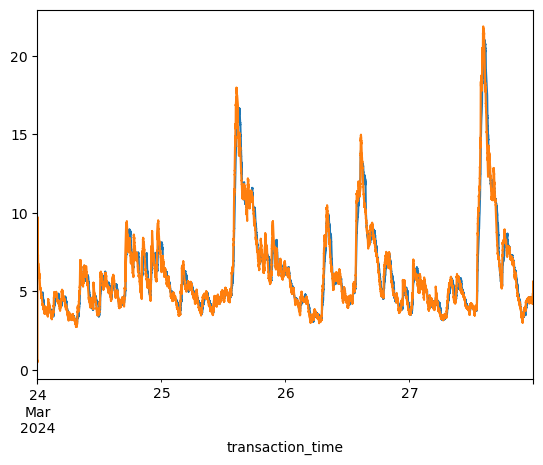

In [9]:
import matplotlib.pyplot as plt

rolling_sigma.plot()
ewma_sigma.plot()
plt.show()

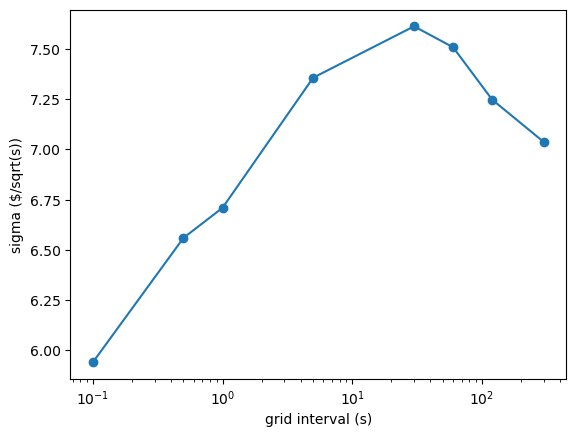

In [10]:
# tuning grid frequency

sigmas = params.sigma.return_grid_sigmas(bt)

x = [params.sigma.to_seconds(f) for f in sigmas.keys()]
y = list(sigmas.values())

plt.plot(x, y, marker = 'o')
plt.xscale('log')
plt.xlabel('grid interval (s)')
plt.ylabel('sigma ($/sqrt(s))')
plt.show()

In [11]:
import params.intensity

matched = params.intensity.match_trades(at, deduped)
matched = params.sigma.slice_window(matched)

In [12]:
matched

,first_trade_id,last_trade_id,price,quantity,is_buyer_maker,mid_price
transact_time,,,,,,
2024-03-24 00:00:00.088,4790419953,4790419970,64020.4,3.194,False,64020.35
2024-03-24 00:00:00.094,4790419971,4790419971,64021.2,0.003,False,64021.15
2024-03-24 00:00:00.094,4790419972,4790419972,64022.0,0.002,False,64021.15
2024-03-24 00:00:00.094,4790419973,4790419973,64022.2,0.004,False,64021.15
2024-03-24 00:00:00.095,4790419974,4790419974,64023.8,0.004,False,64023.75
...,...,...,...,...,...,...
2024-03-27 23:59:58.974,4809660385,4809660385,69532.6,0.007,True,69532.65
2024-03-27 23:59:59.078,4809660386,4809660386,69532.7,0.018,False,69532.65
2024-03-27 23:59:59.113,4809660387,4809660387,69532.6,0.014,True,69532.65


In [13]:
spreads = params.intensity.calculate_spread(matched)

<Axes: xlabel='transact_time'>

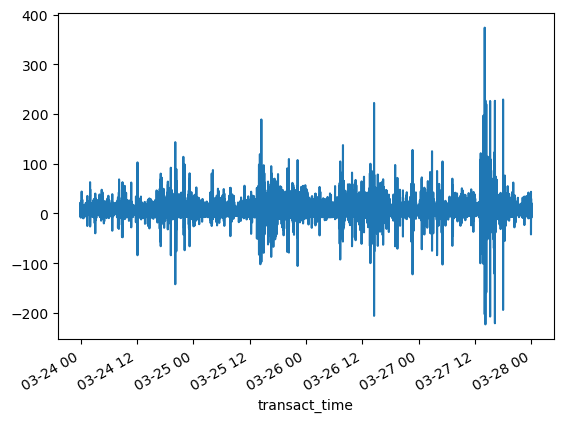

In [14]:
spreads['depth'].plot()

In [15]:
spreads['depth'].describe()

count    7.740801e+06
mean     3.958039e+00
std      1.051197e+01
min     -2.230500e+02
25%      5.000000e-02
50%      6.500000e-01
75%      3.450000e+00
max      3.736000e+02
Name: depth, dtype: float64

In [16]:
(spreads['depth'] < 0).mean()

np.float64(0.004643963848185737)

In [17]:
spreads

,first_trade_id,last_trade_id,price,quantity,is_buyer_maker,mid_price,depth
transact_time,,,,,,,
2024-03-24 00:00:00.088,4790419953,4790419970,64020.4,3.194,False,64020.35,0.05
2024-03-24 00:00:00.094,4790419971,4790419971,64021.2,0.003,False,64021.15,0.05
2024-03-24 00:00:00.094,4790419972,4790419972,64022.0,0.002,False,64021.15,0.85
2024-03-24 00:00:00.094,4790419973,4790419973,64022.2,0.004,False,64021.15,1.05
2024-03-24 00:00:00.095,4790419974,4790419974,64023.8,0.004,False,64023.75,0.05
...,...,...,...,...,...,...,...
2024-03-27 23:59:58.974,4809660385,4809660385,69532.6,0.007,True,69532.65,0.05
2024-03-27 23:59:59.078,4809660386,4809660386,69532.7,0.018,False,69532.65,0.05
2024-03-27 23:59:59.113,4809660387,4809660387,69532.6,0.014,True,69532.65,0.05


In [18]:
sample = spreads.loc[
    (spreads.index >= '2024-03-24 03:00:00') &
    (spreads.index <  '2024-03-24 03:01:00'),
    ['price', 'mid_price', 'is_buyer_maker', 'depth']
]
print(sample.head(10))

                           price  mid_price  is_buyer_maker  depth
transact_time                                                     
2024-03-24 03:00:00.016  64315.7   64315.65           False   0.05
2024-03-24 03:00:00.043  64315.6   64315.65            True   0.05
2024-03-24 03:00:00.186  64315.7   64315.65           False   0.05
2024-03-24 03:00:00.186  64315.9   64315.65           False   0.25
2024-03-24 03:00:00.389  64315.9   64315.85           False   0.05
2024-03-24 03:00:00.441  64316.4   64315.85           False   0.55
2024-03-24 03:00:00.441  64316.5   64315.85           False   0.65
2024-03-24 03:00:00.441  64316.7   64315.85           False   0.85
2024-03-24 03:00:00.441  64317.0   64315.85           False   1.15
2024-03-24 03:00:00.468  64317.2   64317.25            True   0.05


In [19]:
events = params.intensity.event_aggregation(spreads)

In [20]:
events

,max_depth,trade_quantity,is_buyer_maker,price_min,price_max,event_id
transact_time,,,,,,
2024-03-24 00:00:00.088,0.05,3.194,False,64020.4,64020.4,1
2024-03-24 00:00:00.094,1.05,0.013,False,64021.2,64023.8,2
2024-03-24 00:00:00.114,0.05,0.019,False,64024.8,64024.8,3
2024-03-24 00:00:00.150,0.05,0.026,True,64025.0,64025.0,4
2024-03-24 00:00:00.253,0.05,0.032,False,64025.1,64025.1,5
...,...,...,...,...,...,...
2024-03-27 23:59:58.974,0.05,0.007,True,69532.6,69532.6,3296515
2024-03-27 23:59:59.078,0.05,0.018,False,69532.7,69532.7,3296516
2024-03-27 23:59:59.113,0.05,0.014,True,69532.6,69532.6,3296517


In [21]:
sample = events.loc[
    (events.index >= '2024-03-24 03:00:00') &
    (events.index <  '2024-03-24 03:01:00'),
    ['max_depth', 'trade_quantity', 'is_buyer_maker', 'price_min', 'price_max']
]
print(sample.head(10))

                         max_depth  trade_quantity  is_buyer_maker  price_min  \
transact_time                                                                   
2024-03-24 03:00:00.016       0.05           0.021           False    64315.7   
2024-03-24 03:00:00.043       0.05           0.020            True    64315.6   
2024-03-24 03:00:00.186       0.25           0.012           False    64315.7   
2024-03-24 03:00:00.389       0.05           0.134           False    64315.9   
2024-03-24 03:00:00.441       1.15           0.048           False    64316.4   
2024-03-24 03:00:00.468       0.05           0.130            True    64317.2   
2024-03-24 03:00:00.525       0.05           0.010           False    64317.3   
2024-03-24 03:00:00.548       7.15          10.000            True    64310.1   
2024-03-24 03:00:00.633       0.05           0.022            True    64309.7   
2024-03-24 03:00:00.746       0.05           0.014           False    64309.8   

                         pr

In [22]:
sample = spreads.loc[
    (spreads.index >= '2024-03-24 03:00:00') &
    (spreads.index <  '2024-03-24 03:00:00.5'),
    ['depth', 'quantity', 'is_buyer_maker', 'first_trade_id', 'last_trade_id']
]
sample

,depth,quantity,is_buyer_maker,first_trade_id,last_trade_id
transact_time,,,,,
2024-03-24 03:00:00.016,0.05,0.021,False,4790725713,4790725714
2024-03-24 03:00:00.043,0.05,0.020,True,4790725715,4790725715
2024-03-24 03:00:00.186,0.05,0.007,False,4790725716,4790725718
2024-03-24 03:00:00.186,0.25,0.005,False,4790725719,4790725720
2024-03-24 03:00:00.389,0.05,0.134,False,4790725721,4790725769
2024-03-24 03:00:00.441,0.55,0.004,False,4790725770,4790725772
2024-03-24 03:00:00.441,0.65,0.003,False,4790725773,4790725774
2024-03-24 03:00:00.441,0.85,0.004,False,4790725775,4790725776
2024-03-24 03:00:00.441,1.15,0.037,False,4790725777,4790725793


In [23]:
counts = params.intensity.survival_counts(events)

Text(0, 0.5, 'fill intensity (events / sec)')

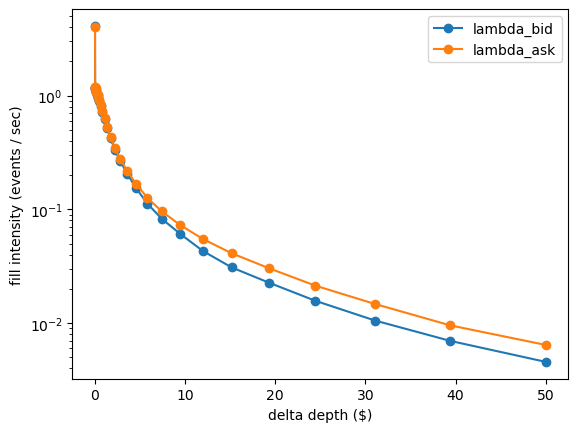

In [24]:
ax = counts[['lambda_bid', 'lambda_ask']].plot(marker = 'o')
ax.set_yscale('log')
ax.set_xlabel('delta depth ($)')
ax.set_ylabel('fill intensity (events / sec)')

In [25]:
sliced_counts = params.intensity.slice_delta(counts)

bid_A, bid_k = params.intensity.regress_intensity(sliced_counts.index, sliced_counts['lambda_bid'])
ask_A, ask_k = params.intensity.regress_intensity(sliced_counts.index, sliced_counts['lambda_ask'])

print(f'bid_A: {bid_A}, bid_k: {bid_k}')
print(f'ask_A: {ask_A}, ask_k: {ask_k}')

bid_A: 1.1250510500004096, bid_k: 0.47557395346534753
ask_A: 1.133880976958078, ask_k: 0.46131051137244206


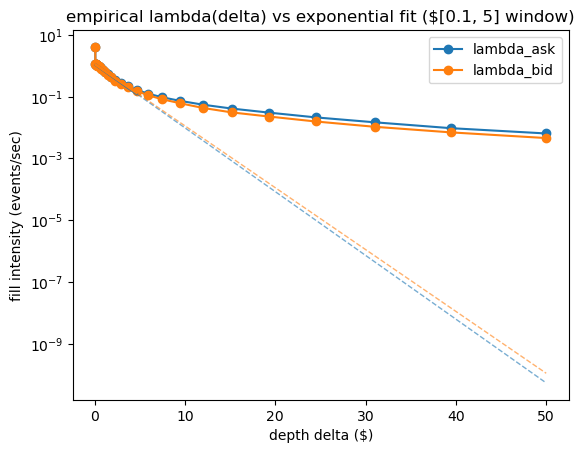

In [26]:
import numpy as np
from config import RESULTS_PATH

low, high = 0.10, 5

ax = counts[['lambda_ask', 'lambda_bid']].plot(marker = 'o')
ax.set_yscale('log')

grid = counts.index.to_numpy()
in_bounds = (grid >= low) & (grid <= high)

for A, k, color in [(bid_A, bid_k, 'C0'), (ask_A, ask_k, 'C1')]:
    lam_fit = A * np.exp(-k * grid)
    ax.plot(grid[in_bounds], lam_fit[in_bounds], color = color, linestyle = '-', linewidth = 2)
    ax.plot(grid[~in_bounds], lam_fit[~in_bounds], color = color, linestyle = '--', linewidth = 1, alpha = 0.6)

ax.set_xlabel('depth delta ($)')
ax.set_ylabel('fill intensity (events/sec)')
ax.set_title(f'empirical lambda(delta) vs exponential fit ($[{low}, {high}] window)')
plt.savefig(RESULTS_PATH / 'depth_intensity.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [27]:
import backtest.strategy

# gamma = 10^-3, sigma = 7, tau = 300, k = 0.47, mid = 67000
# bid should be 66,990.50, ask should be 67009.50

strategy1 = backtest.strategy.Strategy(10**-3, 300, 0.47)
bid, ask = strategy1.quote(67000, 7)
print(f'bid: {bid}, ask: {ask}')

bid: 66990.52460068768, ask: 67009.47539931232


In [28]:
strategy1.q = 5

# skew term = 5*10^-3*49*300 = 73.5
# r should be 66,926.5 ($73.5 below case 1 mid), equal spread of case 1 ($18.95)

bid, ask = strategy1.quote(67000, 7)
print(f'bid: {bid}, ask: {ask}')

bid: 66917.02460068768, ask: 66935.97539931232


In [29]:
strategy1.q = -5

# r should be 67,073.5 ($73.5 below case 1 mid), equal spread of case 1

bid, ask = strategy1.quote(67000, 7)
print(f'bid: {bid}, ask: {ask}')

bid: 67064.02460068768, ask: 67082.97539931232


In [30]:
# testing 1 hour of backtest loop

import backtest.backtester

mid_slice = mid.loc['2024-03-24 03:00':'2024-03-24 04:00']
sigma_slice = ewma_sigma.loc['2024-03-24 03:00':'2024-03-24 04:00']
events_slice = events.loc['2024-03-24 03:00':'2024-03-24 04:00']

strategy = backtest.strategy.Strategy(10**-3, 300, 0.47)
backtester = backtest.backtester.Backtester(strategy, 0.01)

results = backtester.loop(mid_slice, sigma_slice, events_slice)

In [31]:
print(results.isna().sum())

bid_filled       0
ask_filled       0
bid_quote        0
ask_quote        0
bid_id        3278
ask_id        3277
q                0
cash             0
wealth           0
mid              0
dtype: int64


In [32]:
results[['bid_filled', 'ask_filled']].sum()

bid_filled    381
ask_filled    382
dtype: int64

In [33]:
results['q'].iloc[-1]

np.float64(-0.010000000000000004)

<Axes: >

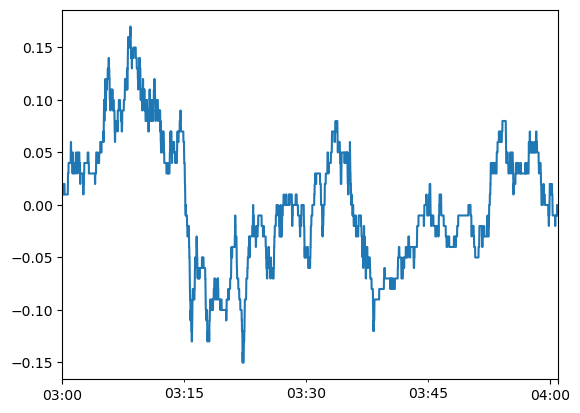

In [34]:
results['q'].plot()

<Axes: >

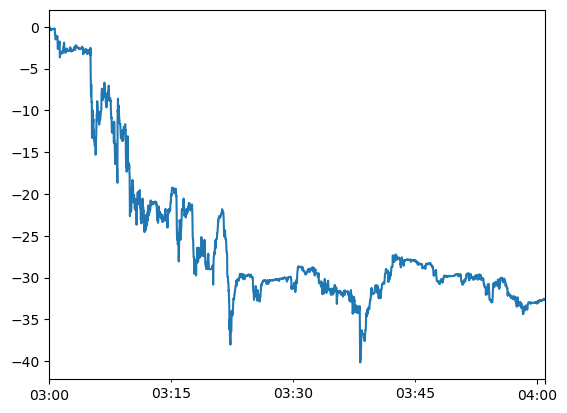

In [35]:
results['wealth'].plot()

In [36]:
(results['ask_quote'] - results['bid_quote']).describe()

count    3659.000000
mean       10.472435
std         0.927409
min         7.811673
25%         9.940511
50%        10.794837
75%        11.173671
max        11.634592
dtype: float64

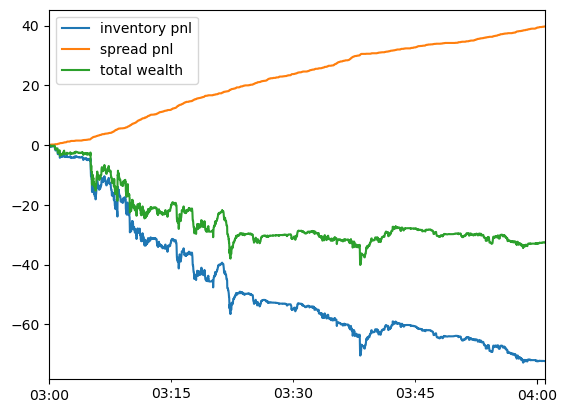

In [37]:
inv_pnl = (results['q'].shift() * results['mid'].diff()).cumsum() # compute inventory riding market movement
spread_pnl = (results['wealth'] - results['wealth'].iloc[0]) - inv_pnl # cash flow

inv_pnl.plot(label = 'inventory pnl')
spread_pnl.plot(label = 'spread pnl')
results['wealth'].plot(label = 'total wealth')
plt.legend()

In [38]:
(results['bid_filled'] & results['ask_filled']).sum()

np.int64(6)

<Axes: >

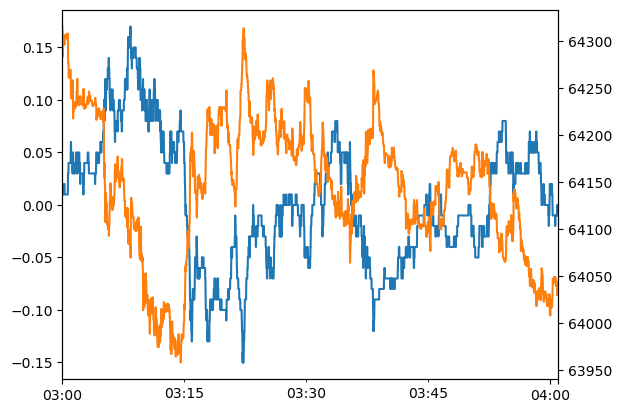

In [39]:
ax = results['q'].plot()
results['mid'].plot(ax = ax, secondary_y = True)

<Axes: xlabel='transaction_time'>

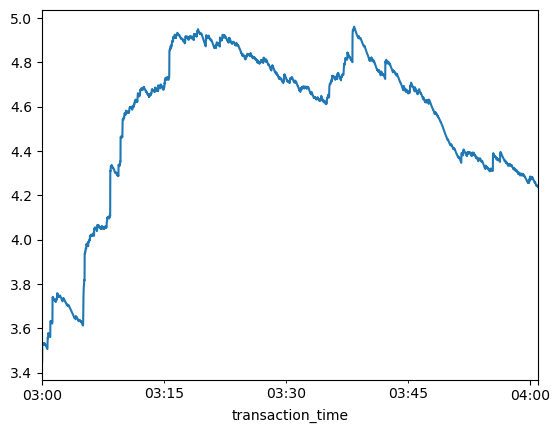

In [40]:
sigma_slice.plot()

In [41]:
# manual trace of backtester to verify

filled = results[results['bid_filled']] # steps where bid was hit
row_t = filled.index[100] # random step
i = results.index.get_loc(row_t)

# check that quote isn't detecting prior events
# seller aggressive -> bid_quote >= price_min
print(results.iloc[i-1:i+1]) 
print(events[events['event_id'] == results['bid_id'].iloc[i]])
print(sigma_slice.loc[row_t])

                     bid_filled  ask_filled     bid_quote     ask_quote  \
2024-03-24 03:11:28       False        True  64001.441686  64012.104204   
2024-03-24 03:11:29        True       False  64010.896333  64021.575179   

                      bid_id   ask_id     q         cash     wealth       mid  
2024-03-24 03:11:28      NaN  65712.0  0.08 -5141.942664 -21.354664  64007.35  
2024-03-24 03:11:29  65724.0      NaN  0.09 -5782.051628 -20.544128  64016.75  
                         max_depth  trade_quantity  is_buyer_maker  price_min  \
transact_time                                                                   
2024-03-24 03:11:29.418       2.95           0.653            True    64010.6   

                         price_max  event_id  
transact_time                                 
2024-03-24 03:11:29.418    64016.0     65724  
4.628912012744778
